# Modeling Latent 90th percentile Exit Velocity and Imputing Missing Bat Speed Data

We first model latent EV90 and then impute missing bat speeds. Much of what follows is from the original paper posted.

In [2]:
import random
from typing import Union
import joblib
import cloudpickle
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 5.28.2
sklearn: 1.8.0
pytensor: 2.38.2
arviz: 0.23.4
arviz_plots: 1.0.0


In [ ]:
df = pd.read_csv('data/input_data.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df[['bips','ev90']].loc[df['ev90']<95]['bips'].describe()

Here we define an index function that takes some input and maps it to 0 to n-1. This will be used by the model to help index the data and essentially label it for the model.

In [5]:
def define_index(data: pd.DataFrame, label: str, plus_one:bool=True) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values
    
    if plus_one:
        index_vals = index_vals + 1
    return index_vals, lookup

In [ ]:
# Here we are just applying the index

# seasonal and month
df['time_lbl'] = df['year'].astype(str) + "-" + df['month_name'].astype(str)
time_list = df[['time_index', 'time_lbl']].drop_duplicates().sort_values('time_index')['time_lbl'].tolist()
time_index_vals = df['time_index'].values.astype("int32")

# Define more indexes for anything to index/filter on
# players
df['player_full_id'] = df['full'] + " (" + df['bam_id'].astype(str) + ")"
player_name_list = pd.unique(df['player_full_id']).tolist()
df["player_idx"], player_lookup = define_index(df, "player_full_id", plus_one=False)
player_index_vals = df['player_idx'].values.astype("int32")

# Note the new column at the end of the dataframe
df.tail(5)

,bam_id,year,month_name,time_index,bips,ev90,swings,bat_speed,obs_type,n_type,...,position,position_group,position_hybrid,region,country,country2,age,time_lbl,player_full_id,player_idx
20140,810938,2026,May,31,26.0,106.55,61.0,69.222951,complete,batspeed_only,...,2B,Defense,UTM,USA,"Virginias, USA","Virginias, USA",25.522245,2026-May,Ben Williamson (810938),1187
20141,814439,2026,Mar/Apr,30,NaN,NaN,NaN,NaN,NaN,NaN,...,CF,Defense,UTM,USA,"Florida, USA","Florida, USA",23.520876,2026-Mar/Apr,Ryan Waldschmidt (814439),1188
20142,814439,2026,May,31,39.0,101.44,95.0,71.868421,complete,batspeed_only,...,CF,Defense,UTM,USA,"Florida, USA","Florida, USA",23.603012,2026-May,Ryan Waldschmidt (814439),1188
20143,823550,2026,Mar/Apr,30,NaN,NaN,NaN,NaN,NaN,NaN,...,2B,Defense,UTM,Pacific,Pacific,Pacific,29.626283,2026-Mar/Apr,Sung-Mun Song (823550),1189
20144,823550,2026,May,31,15.0,101.28,38.0,70.368421,complete,batspeed_only,...,2B,Defense,UTM,Pacific,Pacific,Pacific,29.708419,2026-May,Sung-Mun Song (823550),1189


In [ ]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        az.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

Prior to running the model, we define some empirical means and standard deviations to help our priors.

In [ ]:
# empirical means
mu_emp = np.array([df['ev90'].mean(), df['bat_speed'].mean()])
sigma_emp = np.array([df['ev90'].std(), df['bat_speed'].std()])

print(mu_emp)
print(sigma_emp)

mu_ev90 = mu_emp[0]
sigma_ev90 = sigma_emp[0]

# main data
n_obs = len(df)
ev90_values = df['ev90'].values.astype(float)
bips_values = df['bips'].values.astype(float)

ev90_mask = ~np.isnan(ev90_values) # mask missing ev90 values
ev90_index_vals = np.where(ev90_mask)[0].astype("int32") # indices of observed ev90 values
ev90_observed = ev90_values[ev90_index_vals] 

bips_observed = np.clip(bips_values[ev90_index_vals], 1, 200)
sigma_ev90_observed = sigma_ev90/np.sqrt(bips_observed)

[102.63243117  70.54958895]
[4.803737   2.81339538]


Here we define our model. We applied a measurement error model to learn a player's latent or true EV90, $\theta^{true}_{t,p}$. The general measurement error model is $x^{obs} \sim N(x^{true}, \epsilon)$. Here $x_{obs}$ represents the observed measurement and $x_{true}$ represents the underlying true or latent skill. We extended this framework in two ways. First we scaled the observation noise by the inverse of BIPs to reflect that month estimates with more observations are more reliable. Second, we placed a random walk prior on the latent EV90 to capture within career change and allow it to drift over time rather than have each month be independent. Formally, our EV90 Measurement Error Model for a player $p$ at time $t$ is:
\begin{gather*}
    \theta^{obs}_{t,p} \sim N(\theta^{true}_{t,p}, \frac{\sigma^2_{\theta}}{bips_{t,p}}) \\
    \theta^{true}_{t,p}|\theta^{true}_{t-1,p} \sim N(\theta^{true}_{t-1,p}, \sigma^2_{month}) \\
    \theta^{true}_{0,p} \sim N(\mu, \sigma^2_{p}) \\
    \mu \sim N(\hat{\mu}_{\theta},\hat{\sigma}^2_{\theta}) \\
    \sigma_p \sim HN(1) \quad
    \sigma_{month} \sim HN(1)
\end{gather*}

The first equation is our measurement likelihood: observed EV90 is normally distributed with a latent EV90 and variance inversely proportional to BIPs. The second equation is the random walk: latent EV90 evolves as a Gaussian random walk with variance $\sigma^2_{month}$, which defines how much a player's latent EV90 changes month to month. The third equation is the initial state prior: we draw each player's EV90 from a population distribution with mean $\mu$ and between player variance $\sigma^2_p$. The last lines represent our priors. The population mean has an empirical prior from our observations and we placed weak Half-Normal priors around our variance terms.

In [10]:
coords = {
    "observation_id": np.arange(n_obs),
    "ev90_obs_id": np.arange(len(ev90_index_vals)),
    "time": time_list,
    "time_walk": time_list[1:],
    "player": player_name_list
}

with pm.Model(coords=coords) as model:
    # data
    time_idx = pm.Data("time_idx", time_index_vals, dims=("observation_id",))
    player_idx = pm.Data("player_idx", player_index_vals, dims=("observation_id",))
    ev90_idx = pm.Data('ev90_idx', ev90_index_vals, dims=("ev90_obs_id",))

    # priors
    ## ev90 distribution
    ev90_distribution = pm.Normal('ev90_distribution', mu=mu_ev90, sigma=sigma_ev90)
    ## how much do we expect players to vary from the overall mean ev90 +/- 3*sigma
    sigma_player = pm.HalfNormal('sigma_player', sigma=1.0)
    ## month over month change in ev90
    sigma_month = pm.HalfNormal('sigma_month', sigma=1.0)
    
    # set initial values from N(0,1) dist
    player_init_raw = pm.Normal('player_init_raw', mu=0, sigma=1.0, dims=("player"))
    player_init = pm.Deterministic('player_init', player_init_raw - player_init_raw.mean(), dims="player")
    # player = u_pop + scale*init(0,1)
    player_start = pm.Deterministic('player_start', ev90_distribution + player_init * sigma_player, dims=("player"))
    
    # create matrix of size (n_months_years-1, n_players) of monthly innovations
    # one innovation per player per time step
    month_innovations = pm.Normal('month_innovations', mu=0, sigma=1.0, dims=("time_walk","player"))
    # [0, player],
    # [0+month_innovation_1, player],
    # [0+month_innovation_1+month_innovation_2, player], ...
    walk = pt.concatenate([
        pt.zeros((1, len(coords["player"]))),
        pt.cumsum(month_innovations, axis=0)
    ], axis=0)

    # scale the walk by innovation variance
    monthly_walk = pm.Deterministic('monthly_walk', walk*sigma_month, dims=("time","player"))

    # make player start "first index", then add walk to get innovations over the months
    # [ev90 (from ev90 dist) in month 0, player]
    # [ev90 (from ev90 dist + month_innovation_1), player], ...
    # [ev90 (from ev90 dist + month_innovation_1 + month_innovation_2), player], ...
    theta_ev90 = pm.Deterministic('theta_ev90', player_start[None, :] + monthly_walk, dims=("time","player"))
    theta_ev90_observed = theta_ev90[time_idx, player_idx]

    # lkhood
    pm.Normal('ev90_lkhood', mu=theta_ev90_observed[ev90_idx], sigma=sigma_ev90_observed, observed=ev90_observed, dims=("ev90_obs_id",))



In [ ]:
# Sample via MCMC and NUTS
trace = sample(model, draws = 1000, tune = 1000, target_accept = 0.9,  path='measure_error.nc')

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


After sampling, we check for convergence. The easiest way is inpsecting the Rhat value and seeing if it is below 1.01 for all parameters. Spoiler alert, the model converged. We found the player standard deviation, how much player's differ was 3.7 mph and the monthly deviation was 2.3 mph. Therefore, we expect a player's monthly EV90 to fall within 2.3 mph of their true EV90 about 66\% of the time.

In [12]:
az.summary(trace, var_names=['ev90_distribution','sigma_player','sigma_month'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ev90_distribution,102.544,0.105,102.359,102.755,0.003,0.002,1086.0,1843.0,1.0
sigma_player,3.645,0.117,3.419,3.854,0.004,0.002,950.0,1658.0,1.0
sigma_month,2.285,0.021,2.246,2.326,0.001,0.000,942.0,1783.0,1.0


In [13]:
ev90_df = az.summary(trace, var_names=['theta_ev90']).reset_index(drop=False)
print(ev90_df['r_hat'].max())

1.01


In [14]:
trace_df = az.summary(trace, var_names=['~theta_ev90']).reset_index(drop=False)

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


In [15]:
print(trace_df['r_hat'].max())

1.01


In [16]:
trace_df

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,ev90_distribution,102.544,0.105,102.359,102.755,0.003,0.002,1086.0,1843.0,1.00
1,player_init_raw[Albert Pujols (405395)],0.996,0.163,0.698,1.309,0.003,0.002,3277.0,2981.0,1.00
2,player_init_raw[Miguel Cabrera (408234)],0.792,0.230,0.350,1.213,0.003,0.004,4709.0,2788.0,1.00
3,player_init_raw[Jeff Mathis (425772)],-1.203,0.695,-2.476,0.125,0.008,0.011,8450.0,3148.0,1.00
4,player_init_raw[René Rivera (425784)],0.368,0.589,-0.741,1.455,0.007,0.010,6877.0,2923.0,1.00
...,...,...,...,...,...,...,...,...,...,...
78538,"monthly_walk[2026-May, Hyeseong Kim (808975)]",-1.587,3.604,-8.435,5.060,0.036,0.069,10256.0,2756.0,1.00
78539,"monthly_walk[2026-May, Jung Hoo Lee (808982)]",-3.495,3.521,-9.875,3.199,0.034,0.071,10603.0,2681.0,1.01
78540,"monthly_walk[2026-May, Ben Williamson (810938)]",3.075,3.493,-3.449,9.771,0.036,0.067,9687.0,2971.0,1.00
78541,"monthly_walk[2026-May, Ryan Waldschmidt (814439)]",-0.998,3.463,-7.563,5.318,0.034,0.065,10097.0,2555.0,1.00


Here we use the `az.plot_energy` as a diagnostic in Bayesian MCMC sampling to compare the marginal energy distribution to the energy transition distribution from the sampler. Our objective is to assess how well the sampler is exploring the posterior, with a strong overlap between the two represent efficent exploration of the distribution.

<Axes: >

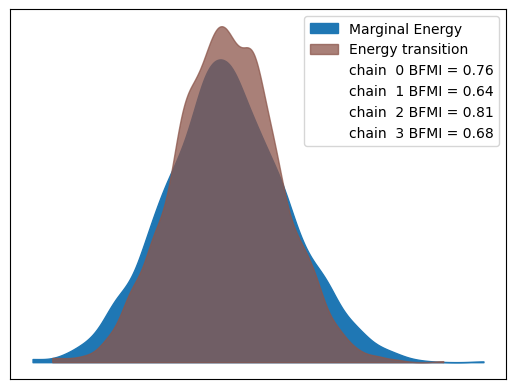

In [17]:
az.plot_energy(trace)

Next we used `azp.plot_rank_dist` to see how the chains mix. We only show for a few parameters because the others have a line for each player and displaying so many players in a single graph is not worthwhile. This convergence check evaluates if the chains are mixing uniformly by comparing the rank distributions of samples across chains. Well-mixed chains should be roughly overlapping, while divergences or separation indicates poor mixing and non-convergence.

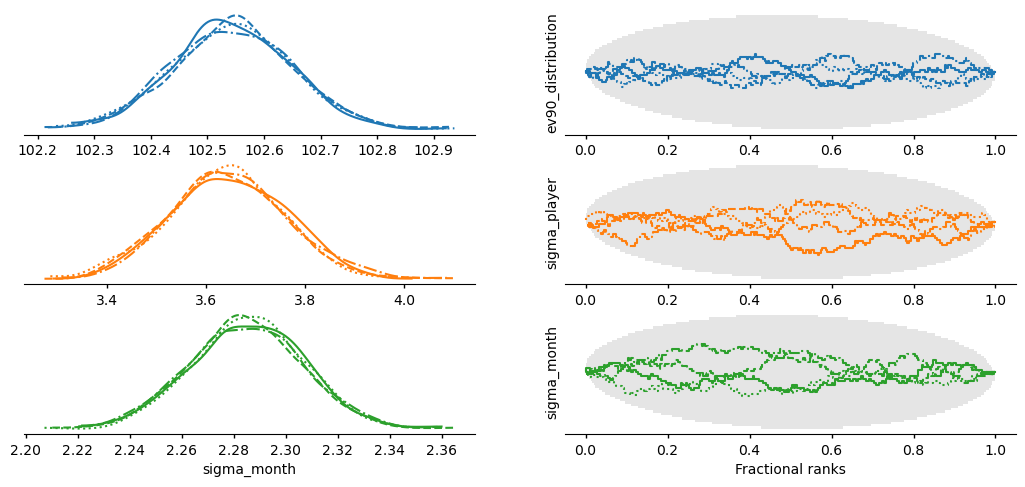

In [18]:
azp.plot_rank_dist(trace, var_names=['ev90_distribution','sigma_player','sigma_month'])

In [19]:
compute_log_likelihood(model, trace)

Output()

In [20]:
spp = sample_posterior_pred(model, trace)

Sampling: [ev90_lkhood]


Output()

Lastly, we evaluated the posterior predictive checks using `az.plot_ppc`, which compares the observed data distribution (black line) to data simulated from the posterior predictive distribution (blue/orange curves). A strong overlap between these distributions indicates the model can reproduce the observed data. If these two lines did not overlap, then the model would be poorly specified even though it converged.

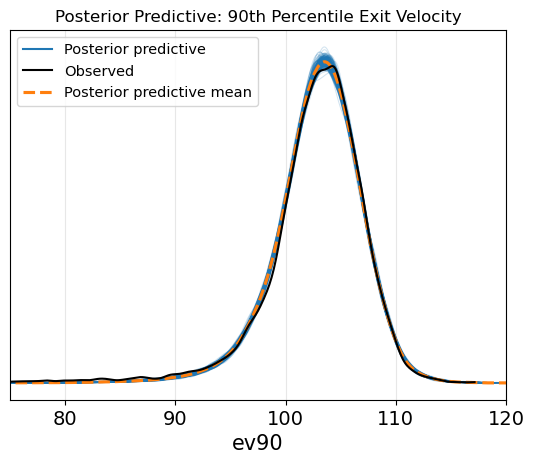

In [21]:
fig, ax0 = plt.subplots()
az.plot_ppc(spp, var_names="ev90_lkhood", num_pp_samples=250, random_seed=RANDOM_SEED, ax=ax0)
ax0.set_title("Posterior Predictive: 90th Percentile Exit Velocity")
ax0.set_xlabel("ev90")
ax0.set_xlim(75,120)
ax0.grid(True, alpha=0.3)

After confirming the model was sufficent, we compare the latent EV90 with the observed EV90.

In [22]:
# make ev90 dataframe with index columns
ev90_df[["year","month_name", "player", "bam_id"]] = ev90_df["index"].str.extract(r'theta_ev90\[(\d+)-(.*?),\s*(.*?)\s*\((\d+)\)\]')
ev90_df['bam_id'] = ev90_df['bam_id'].astype(int)
ev90_df['year'] = ev90_df['year'].astype(int)
cdf = df.merge(ev90_df[['bam_id', 'month_name', 'year', 'mean', 'sd', 'hdi_3%', 'hdi_97%']], on=['bam_id', 'month_name', 'year'])
cdf['latent_ev90'] = cdf['mean']
cdf['latent_ev90_std'] = cdf['sd']
cdf['diff'] = cdf['ev90'] - cdf['mean']
cdf.head(10)

,bam_id,year,month_name,time_index,bips,ev90,swings,bat_speed,obs_type,n_type,...,time_lbl,player_full_id,player_idx,mean,sd,hdi_3%,hdi_97%,latent_ev90,latent_ev90_std,diff
0,405395,2021,Mar/Apr,0,63.0,106.16,NaN,NaN,ev_only,ev_only,...,2021-Mar/Apr,Albert Pujols (405395),0,106.177,0.564,105.122,107.230,106.177,0.564,-0.017
1,405395,2021,May,1,41.0,108.40,NaN,NaN,ev_only,ev_only,...,2021-May,Albert Pujols (405395),0,107.838,0.686,106.528,109.077,107.838,0.686,0.562
2,405395,2021,Jun,2,41.0,103.90,NaN,NaN,ev_only,ev_only,...,2021-Jun,Albert Pujols (405395),0,104.412,0.686,103.055,105.647,104.412,0.686,-0.512
3,405395,2021,Jul,3,44.0,105.79,NaN,NaN,ev_only,ev_only,...,2021-Jul,Albert Pujols (405395),0,105.652,0.666,104.444,106.931,105.652,0.666,0.138
4,405395,2021,Aug,4,19.0,105.56,NaN,NaN,ev_only,incomplete,...,2021-Aug,Albert Pujols (405395),0,105.493,0.937,103.687,107.209,105.493,0.937,0.067
5,405395,2021,Sep/Oct,5,24.0,105.10,NaN,NaN,ev_only,incomplete,...,2021-Sep/Oct,Albert Pujols (405395),0,105.093,0.860,103.523,106.751,105.093,0.860,0.007
6,405395,2022,Mar/Apr,6,24.0,104.63,NaN,NaN,ev_only,incomplete,...,2022-Mar/Apr,Albert Pujols (405395),0,104.641,0.833,103.132,106.248,104.641,0.833,-0.011
7,405395,2022,May,7,41.0,104.10,NaN,NaN,ev_only,ev_only,...,2022-May,Albert Pujols (405395),0,104.248,0.697,102.882,105.520,104.248,0.697,-0.148
8,405395,2022,Jun,8,29.0,105.14,NaN,NaN,ev_only,incomplete,...,2022-Jun,Albert Pujols (405395),0,105.325,0.780,103.833,106.739,105.325,0.780,-0.185
9,405395,2022,Jul,9,44.0,107.85,NaN,NaN,ev_only,ev_only,...,2022-Jul,Albert Pujols (405395),0,107.581,0.662,106.351,108.791,107.581,0.662,0.269


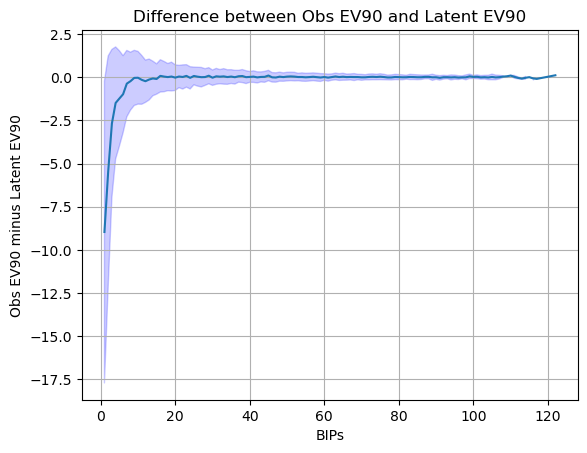

In [23]:
g = cdf.groupby('bips').agg(
    ev90_diff=('diff', 'mean'),
    ev90_diff_sd=('diff', 'std'),
    ss=('diff','count')
).reset_index(drop=False)


plt.plot(g['bips'], g['ev90_diff'])
plt.fill_between(g['bips'],  g['ev90_diff']-g["ev90_diff_sd"],  g['ev90_diff']+g["ev90_diff_sd"], alpha=0.2, color='blue')
plt.xlabel('BIPs')
plt.ylabel('Obs EV90 minus Latent EV90')
plt.title('Difference between Obs EV90 and Latent EV90')
plt.grid(True)

To illustrate the difference between the observed and latent EV90, we computed their difference and averaged over BIPs. In the figure above, the shaded area represents 1 standard deviation from the difference.  For player-month observations with a low number of BIPs, the latent EV90 was higher than their observed EV90. After 40 BIPs, there was little difference between the measurements.

In [24]:
def plot_performance(df: pd.DataFrame, bam_id: int, ax=None, yticks=np.arange(75, 121, 5)):
    
    d = df.loc[df["bam_id"] == bam_id].reset_index()
    d_valid = d[d["ev90"].notna()]
    d = d[(d["time_index"] >= d_valid["time_index"].min()-1) & (d["time_index"] <= d_valid["time_index"].max()+1)]
    name = d['full'].iloc[0] + "\n" + str(bam_id) + ""

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(15, 4))
   
    ax.scatter(d['time_index'], d['ev90'], color='red', label='Observed')
    ax.errorbar(d["time_index"],  d["ev90"], yerr=sigma_ev90 / np.sqrt(d["bips"]), fmt='none', color='red')
    ax.plot(d["time_index"], d["mean"], color = 'blue', label='Latent')
    ax.fill_between(d["time_index"],  d["mean"]-d["sd"],  d["mean"]+d["sd"], alpha=0.2, color='blue')
    ax.set_xticks(d["time_index"])
    
    lbsl = [lbl.replace("-", "\n") for lbl in d["time_lbl"]]
    ax.set_xticklabels(lbsl, rotation=35, fontsize=8)
    ax.set_ylabel('EV90 (mph)')
    ax.set_ylim(min(yticks), max(yticks))
    ax.set_yticks(yticks)
    ax.grid(True)
    ax.set_title(name, fontsize=14)
    
    return ax

Now we plot some players to compare the observed EV90 (red) to their latent EV90 (blue). These players were hand picked after looking at the data. The latent EV90 really comes into play for players with spare months of data. We added red error bars as the observed standard deviation of EV90 divided by the square root of their BIPs and shaded the latent EV90's standard deviation. Months with spare data will have longer red bars.

<Axes: title={'center': 'Jo Adell\n666176'}, ylabel='EV90 (mph)'>

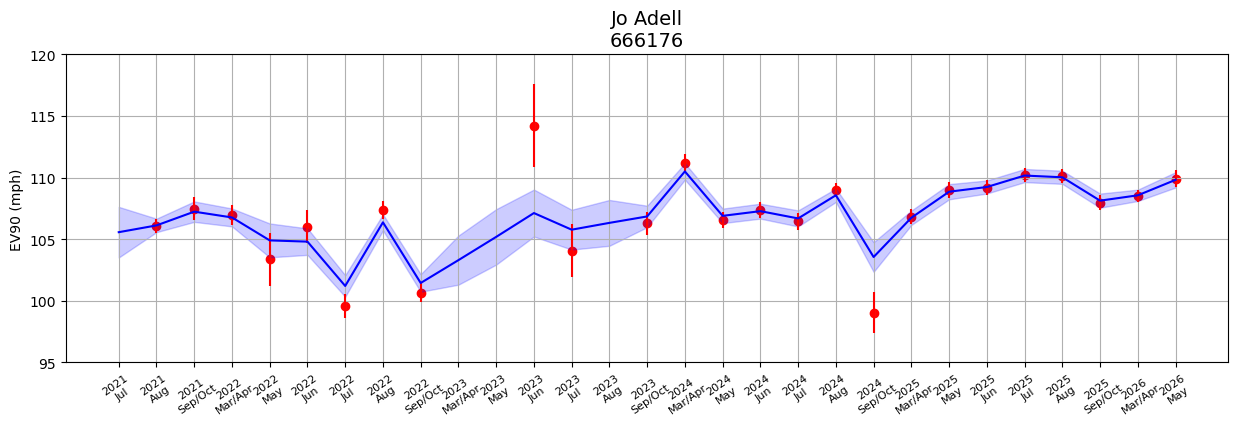

In [25]:
plot_performance(cdf, 666176, yticks=np.arange(95, 121, 5))

<Axes: title={'center': 'Zack Short\n670097'}, ylabel='EV90 (mph)'>

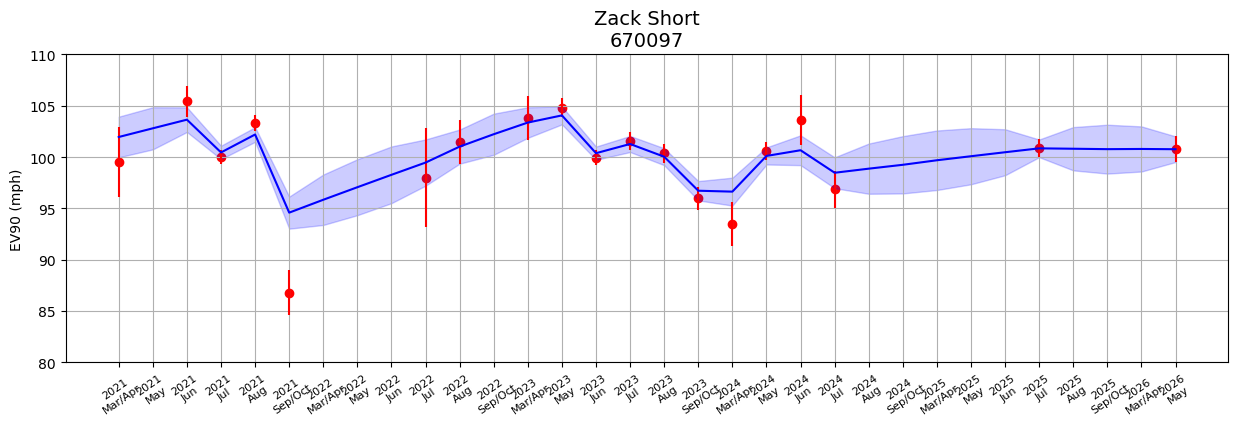

In [26]:
plot_performance(cdf, 670097, yticks=np.arange(80, 111, 5))

<Axes: title={'center': 'Luke Williams\n663897'}, ylabel='EV90 (mph)'>

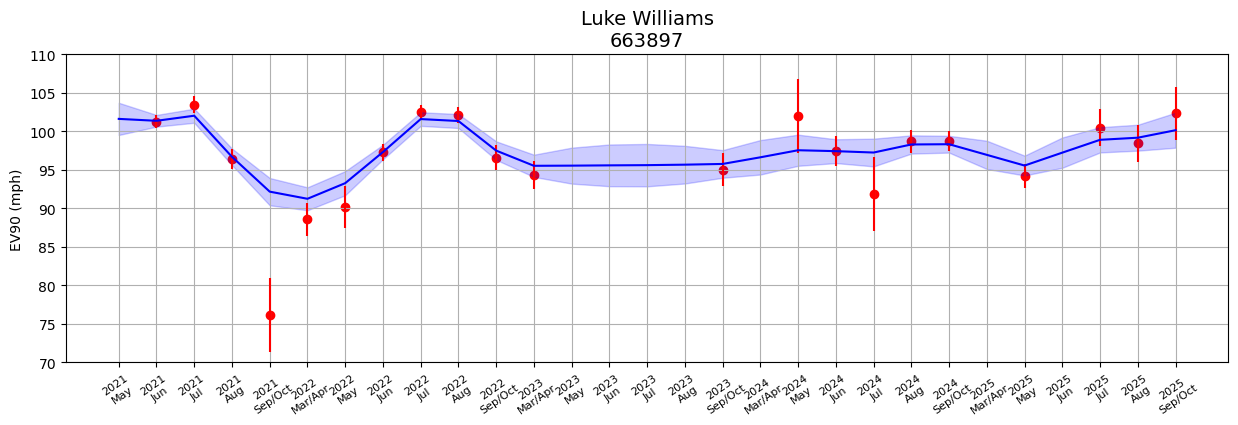

In [27]:
plot_performance(cdf, 663897, yticks=np.arange(70, 111, 5))

<Axes: title={'center': 'J.T. Realmuto\n592663'}, ylabel='EV90 (mph)'>

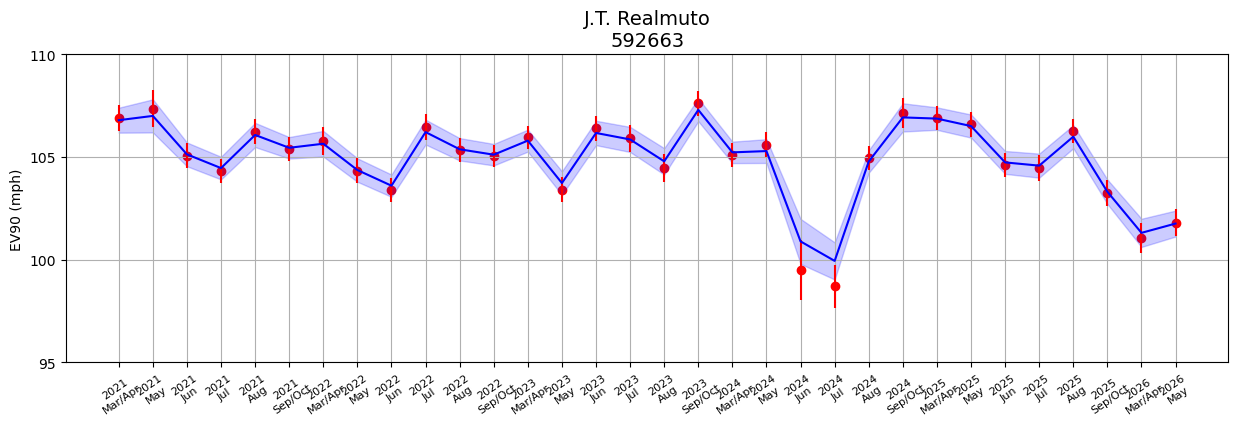

In [ ]:
# JT has a much more stable latent EV90 that mirrors his observed because he plays more frequently and is better than the two above players.
plot_performance(cdf, 592663, yticks=np.arange(95, 111, 5))

# Missing Bat Speed data

In [48]:
# here we are setting up the data
MIN_SWINGS = 10
MIN_BIPS=40
cdf['is_complete'] = np.where((cdf['swings']>=MIN_SWINGS)&(cdf['bips']>=MIN_BIPS), 1, 0)
complete_mask = cdf['is_complete'] == 1
cdf['bat_speed_complete'] = np.where(complete_mask, cdf['bat_speed'], np.nan)


latent_ev90 = cdf['latent_ev90'].values.astype(float)
bat_speed = cdf['bat_speed'].values.astype(float)

joint_obs = np.stack([latent_ev90[complete_mask], bat_speed[complete_mask]], axis=1).astype(float)

complete_index_vals = np.where(complete_mask)[0].astype("int32") # indices of observed bat speed values with >=MIN_SWINGS and >=MIN_BIPS

mean_latent_ev90 = latent_ev90.mean()
mean_bat_speed = np.nanmean(bat_speed)
sigma_latent_ev90 = latent_ev90.std()
sigma_bat_speed = np.nanstd(bat_speed)

We first learned the joint MvN between latent EV90 and Bat Speed on observations with at least 40 BIPs and 10 Swings. Even though the latent EV90 metric was less noisy than observed EV90, observations with less than 40 BIPs still contained a latent EV90 with a larger than desired variance. Second, we used observations with at least 10 Swings given past experience. Since the missing bat speed data was missing completely at random, we sampled from the multivariate normal distribution (MvN) of our observed values. We first learned the joint multivariate normal between latent EV90 and observed bat speed, restricting to player-months with at least 40 BIPs and at least 10 swings. In our dataset of monthly observations, the empirical correlation between latent EV90 and observed bat speed was $0.81$, corresponding to an $R^2 = 0.81^2 = 0.65$.

Formally, we model the joint distribution of latent EV90 and bat speed as a multivariate normal:
\begin{gather*}
\begin{bmatrix}
\theta^{true}_i \\
BS_i
\end{bmatrix}
\sim
N
\left(
\begin{bmatrix}
\mu_\theta \\
\mu_{BS}
\end{bmatrix},
\Sigma
\right) \\
\qquad
\Sigma = LL^T =
\begin{bmatrix}
\sigma_\theta^2 & \rho \sigma_\theta \sigma_{BS} \\
\rho \sigma_\theta \sigma_{BS} & \sigma_{BS}^2
\end{bmatrix}
\\
\mu_{\theta} \sim N(\hat{\mu}_\theta, 1) \quad
\mu_{BS} \sim N(\hat{\mu}_{BS}, 1) \\
L \sim \text{LKJCholeskyCov}(\eta=2, \sigma = \hat{\sigma}^2)
\end{gather*}

In [31]:
coords = {
    "complete_obs_id": np.arange(complete_mask.sum()),
    "metric": ['ev90','bat_speed']
}

with pm.Model(coords=coords) as model:
    mu_vec = pm.Normal("mu_vec",
                       mu= np.array([mean_latent_ev90, mean_bat_speed]),
                       sigma = np.array([0.5, 0.5]),
                       shape = 2
    )
    # cholesky
    chol, corr, stds = pm.LKJCholeskyCov("chol", n=2, eta=2.0,
                                            sd_dist=pm.HalfNormal.dist(
                                                sigma=np.array([sigma_latent_ev90, sigma_bat_speed]),
                                                shape=2
                                            )
                                        )
    pm.MvNormal("joint", mu=mu_vec, chol=chol, observed=joint_obs, dims=("complete_obs_id", "metric"))


In [32]:
trace_mvn = sample(model, draws = 2000, tune = 2000, target_accept = 0.9, path='mvn.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [33]:
az.summary(trace_mvn, var_names=['mu_vec','chol','chol_corr','chol_stds'])

/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/homebrew/Caskroom/miniforge/base/envs/pie/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_vec[0],104.267,0.043,104.185,104.346,0.001,0.0,4595.0,5080.0,1.0
mu_vec[1],70.820,0.041,70.742,70.897,0.001,0.0,4661.0,5281.0,1.0
chol[0],2.915,0.031,2.855,2.972,0.000,0.0,5017.0,5580.0,1.0
chol[1],2.259,0.033,2.197,2.321,0.000,0.0,4896.0,5395.0,1.0
chol[2],1.554,0.017,1.521,1.585,0.000,0.0,6453.0,5319.0,1.0
"chol_corr[0, 0]",1.000,0.000,1.000,1.000,0.000,NaN,8000.0,8000.0,NaN
"chol_corr[0, 1]",0.824,0.005,0.815,0.833,0.000,0.0,5382.0,5483.0,1.0
"chol_corr[1, 0]",0.824,0.005,0.815,0.833,0.000,0.0,5382.0,5483.0,1.0
"chol_corr[1, 1]",1.000,0.000,1.000,1.000,0.000,0.0,8046.0,8000.0,1.0
chol_stds[0],2.915,0.031,2.855,2.972,0.000,0.0,5017.0,5580.0,1.0


In [ ]:
# grab posterior distributions
l00_post = trace_mvn.posterior["chol"].values[:,:,0]
l10_post = trace_mvn.posterior["chol"].values[:,:,1]
l11_post = trace_mvn.posterior["chol"].values[:,:,2]
mu_bs_post = trace_mvn.posterior["mu_vec"].values[:,:,1]
mu_ev_post = trace_mvn.posterior["mu_vec"].values[:,:,0]

# weight or beta coefficent
print(np.mean(l10_post/l00_post))

After sampling, we computed a posterior correlation of 0.824 with a 94\% HDI between 0.815 and 0.833, very close to our empirical estimate. Since sampling from the conditional distribution is analogous to the regression of bat speed on latent EV90, we interpreted $L_{10}/L_{00}=0.78$ as follows: for every 1 mph increase in a player's latent EV90 in a given month, their expected bat speed increases by 0.777 mph, holding all else equal. 

For player-months where bat speed is unobserved, we impute by sampling from the conditional distribution. To propagate uncertainty from both the Cholesky and the latent EV90, for each posterior draw we sample the latent EV90 for a player $p$ in time period $t$: $\theta^{\text{true}}_{t,p} \sim \mathcal{N}\left(\hat{\theta}^{\text{true}}_{t,p},\ \hat{\sigma}^2_{\theta,t,p}\right)$. Then, at the observation level, we draw the imputed bat speed: $\text{BS}^{\text{imp}}_{i} \sim \mathcal{N}\left(\mu_{\text{BS}} + \frac{L_{10}}{L_{00}}\left(\theta^{\text{true}}_{i} - \mu_\theta\right),\ L^2_{11}\right)$.

In [ ]:
latent_ev90 = cdf['latent_ev90'].values.astype(float)
latent_ev90_std = cdf['latent_ev90_std'].values.astype(float)
rng = np.random.default_rng(RANDOM_SEED)
n_chains = mu_bs_post.shape[0]
n_draws  = mu_bs_post.shape[1]
latent_ev90_dist = latent_ev90[None, None, :] + rng.normal(0, 1, size=(n_chains, n_draws, len(latent_ev90))) * latent_ev90_std[None, None, :]
cond_dist = mu_bs_post[:,:,None]+ (l10_post/l00_post)[:,:,None]*(latent_ev90_dist - mu_ev_post[:,:,None])
cond_dist = cond_dist + rng.normal(0, l11_post[:,:,None])
cond_mean = cond_dist.mean(axis=(0,1))
cond_std = cond_dist.std(axis=(0,1))

cdf['imputed_bat_speed'] = cond_mean
cdf['imputed_bat_speed_std'] = cond_std
cdf['model_bat_speed'] = np.where(cdf['bat_speed'].isna(),cdf['imputed_bat_speed'], cdf['bat_speed'])

# re calc just in case
bat_speed = cdf['bat_speed'].values.astype(float)
sigma_bat_speed = np.nanstd(bat_speed)
cdf['model_bat_speed_std'] = np.where(cdf['bat_speed'].isna(), cdf['imputed_bat_speed_std'], sigma_bat_speed/np.sqrt(cdf['swings']))

cdf.head()

To validate the imputation, we computed the root mean squared error between imputed and observed bat speed, which indicated the imputation recovered observed bat speed within 1.55 mph on average. Also, the residual standard deviation $L_{11}=1.55$ mph represented the irreducible uncertainty in bat speed after conditioning on latent EV90. This is the variation in bat speed among players with the same latent EV90.

In [52]:
# estimating performance
preds = cdf['imputed_bat_speed'].loc[cdf['is_complete']==1]
true = cdf['bat_speed'].loc[cdf['is_complete']==1]
print(round(mean_squared_error(true, preds),2))
print(round(np.sqrt(mean_squared_error(true, preds)),2))
print(round(sigma_bat_speed,2))
print(round(np.mean(l11_post),2))

2.41
1.55
2.81
1.55


In [46]:
cdf = cdf[[
    'bam_id','year','month_name','time_index',
    'player_full_id','full','first','last',	'bats',	'birth_date','position','position_group','position_hybrid',	'region','country',	'country2',
    'age','bips','ev90','latent_ev90','latent_ev90_std',
    'swings','bat_speed','imputed_bat_speed','imputed_bat_speed_std',
    'model_bat_speed','model_bat_speed_std'
]]
cdf = cdf.loc[~((cdf['bips'].isna())&(cdf['swings'].isna()))]
cdf.to_csv('data/bat_speed_model_data.csv',index=False)